Inference time: 0.5933589935302734 seconds
Generated image for prompt: sailing ship in storm by Leonardo da Vinci
Total time taken: 0.5943722724914551 seconds


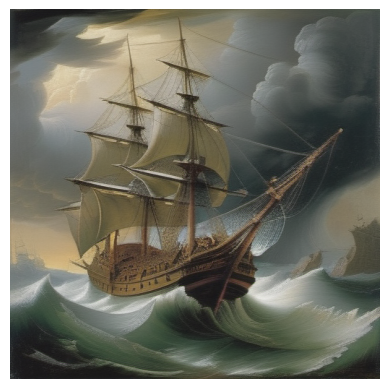

In [5]:
import sys
import tritonclient.grpc as grpcclient
import numpy as np
import time

# Configuration
model_name = "stable_diffusion_xl"
server_url = "localhost:8001"

try:
    triton_client = grpcclient.InferenceServerClient(url=server_url)
except Exception as e:
    print(f"channel creation failed: {str(e)}")
    sys.exit(1)

def generate_image(prompt: str, negative_prompt: str, seed: int):
    # Create input tensors
    inputs = []
    inputs.append(grpcclient.InferInput("prompt", [1, 1], "BYTES"))
    inputs.append(grpcclient.InferInput("negative_prompt", [1, 1], "BYTES"))
    # Add seed parameter to the input tensors
    inputs.append(grpcclient.InferInput("seed", [1, 1], "INT32"))


    # Set input data
    inputs[0].set_data_from_numpy(np.array([[prompt]], dtype=np.object_))
    inputs[1].set_data_from_numpy(np.array([[negative_prompt]], dtype=np.object_))
    inputs[2].set_data_from_numpy(np.array([[seed]], dtype=np.int32))

    # Create output tensor
    outputs = []
    outputs.append(grpcclient.InferRequestedOutput("generated_image"))

    # Send request to Triton server
    start_time = time.time()
    results = triton_client.infer(model_name=model_name, inputs=inputs, outputs=outputs)
    end_time = time.time()

    # Calculate and print the time taken for inference
    print(f"Inference time: {end_time - start_time} seconds")

    # Get the output data
    generated_image = results.as_numpy("generated_image")
    return generated_image

# prompts = [
#     "apple",
#     "orange",
#     "banana",
#     "coconut",
#     "strawberry",
#     "blueberry",
#     "raspberry",
# ]

seed = 42

prompts = [
    "sailing ship in storm by Leonardo da Vinci"
]

negative_prompts = "out of frame, nude, duplicate, watermark, signature, mutated, text, blurry, worst quality, low quality, artificial, texture artifacts, jpeg artifacts"

import concurrent.futures

def generate_images_in_parallel(prompts, negative_prompt):
    with concurrent.futures.ThreadPoolExecutor() as executor:
        images = []
        start_time = time.time()

        future_to_prompt = {executor.submit(generate_image, prompt, negative_prompt, seed): prompt for prompt in prompts}
        for future in concurrent.futures.as_completed(future_to_prompt):
            prompt = future_to_prompt[future]
            try:
                generated_image = future.result()
                images.append(generated_image)

                print(f"Generated image for prompt: {prompt}")
                # You can add code here to handle the generated image, e.g., save it or display it
            except Exception as exc:
                print(f"Prompt {prompt} generated an exception: {exc}")
        
        end_time = time.time()
        print(f"Total time taken: {end_time - start_time} seconds")

        return images

images = generate_images_in_parallel(prompts, negative_prompts)


import matplotlib.pyplot as plt

plt.imshow(images[0][0])
plt.axis('off')
plt.show()

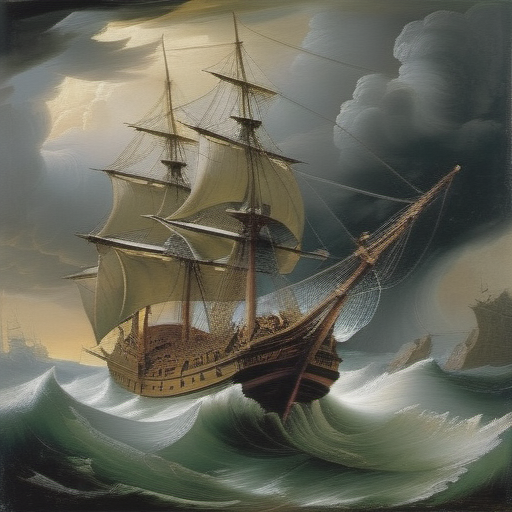

In [6]:
import PIL
PIL.Image.fromarray(images[0][0])